In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import shutil

BASE_DIR = Path("/content/drive/MyDrive/DIS_PROJESI_007")

RESULTS_ROOT = BASE_DIR / "results"
FINAL_MODELS_ROOT = BASE_DIR / "final_models"

DENTEX_RESULTS = RESULTS_ROOT / "dentex_training"
ALPHADENT_RESULTS = RESULTS_ROOT / "alphadent_training"
INTRAORAL_RESULTS = RESULTS_ROOT / "intraoral_caries_training"
DEEPLAB_RESULTS = RESULTS_ROOT / "alphadent_deeplab"

GENERAL_RESULTS = RESULTS_ROOT / "general_project_summary"
GENERAL_RESULTS.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("GENERAL_RESULTS:", GENERAL_RESULTS)

BASE_DIR: /content/drive/MyDrive/DIS_PROJESI_007
GENERAL_RESULTS: /content/drive/MyDrive/DIS_PROJESI_007/results/general_project_summary


In [3]:
dentex_csv = DENTEX_RESULTS / "dentex_all_models_report_table.csv"

print("DENTEX CSV:", dentex_csv)
print("Var mı?:", dentex_csv.exists())

df_dentex = pd.read_csv(dentex_csv)
df_dentex

DENTEX CSV: /content/drive/MyDrive/DIS_PROJESI_007/results/dentex_training/dentex_all_models_report_table.csv
Var mı?: True


,model,architecture_type,model_size,task,experiment_type,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,run_name,description
0,RT-DETR-l,Transformer-based detection,large,object detection,first_round,640,30,4,0.684156,0.133065,0.022853,0.005516,rtdetr_l_640_30ep,Gerçek zamanlı Transformer tabanlı nesne tespi...
1,YOLO11s,YOLO detection,small,object detection,first_round,768,30,8,0.017453,0.448302,0.021067,0.006000,yolo11s_768_30ep,Güncel YOLO ailesinden küçük ölçekli detection...
2,RT-DETR-l,Transformer-based detection,large,object detection,fine_tune,768,100,4,0.680612,0.086022,0.015950,0.004531,rtdetr_l_768_100ep_finetune_batch4,Gerçek zamanlı Transformer tabanlı nesne tespi...
3,YOLOv8s,YOLO detection,small,object detection,first_round,768,30,8,0.014987,0.435874,0.015872,0.004526,yolov8s_768_30ep,Hız ve başarı dengesi için kullanılan YOLOv8 m...
4,YOLOv8n,YOLO detection,nano,object detection,first_round,640,30,8,0.005913,0.404039,0.014097,0.004037,yolov8n_640_30ep,Hızlı ve hafif YOLOv8 modeli
5,YOLOv8m,YOLO detection,medium,object detection,first_round,768,30,4,0.006297,0.389171,0.013507,0.003940,yolov8m_768_30ep,Daha yüksek kapasiteye sahip YOLOv8 modeli


In [4]:
alphadent_csv = ALPHADENT_RESULTS / "alphadent_all_seg_models_report_table.csv"

print("AlphaDent CSV:", alphadent_csv)
print("Var mı?:", alphadent_csv.exists())

df_alphadent = pd.read_csv(alphadent_csv)
df_alphadent

AlphaDent CSV: /content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_training/alphadent_all_seg_models_report_table.csv
Var mı?: True


,model,architecture_type,model_size,task,imgsz,epochs,batch,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95,run_name,description
0,YOLOv8m-seg,YOLO instance segmentation,medium,instance segmentation,640,30,4,0.578482,0.623575,0.620584,0.459795,0.613126,0.585585,0.612124,0.411457,yolov8m_seg_640_30ep,Daha yüksek kapasiteye sahip YOLOv8 segmentasy...
1,YOLOv8m-seg,YOLO instance segmentation,medium,instance segmentation,768,75,4,0.530670,0.639962,0.617483,0.457998,0.591057,0.601421,0.608167,0.413483,yolov8m_seg_768_75ep_finetune,Daha yüksek kapasiteye sahip YOLOv8 segmentasy...
2,YOLO11s-seg,YOLO instance segmentation,small,instance segmentation,640,30,8,0.558936,0.588657,0.601638,0.438696,0.531689,0.605506,0.593423,0.395781,yolo11s_seg_640_30ep,Güncel YOLO ailesinden küçük ölçekli segmentas...
3,YOLOv8n-seg,YOLO instance segmentation,nano,instance segmentation,640,30,8,0.553011,0.600889,0.592514,0.435657,0.559407,0.602827,0.589347,0.391522,yolov8n_seg_640_30ep,Hızlı ve hafif YOLOv8 segmentasyon modeli
4,YOLOv8s-seg,YOLO instance segmentation,small,instance segmentation,640,30,8,0.569006,0.620811,0.605136,0.439920,0.563801,0.622749,0.582481,0.390327,yolov8s_seg_640_30ep,Hız ve başarı dengesi için kullanılan YOLOv8 s...


In [5]:
intraoral_csv = INTRAORAL_RESULTS / "intraoral_all_models_report_table.csv"

print("Intraoral CSV:", intraoral_csv)
print("Var mı?:", intraoral_csv.exists())

df_intraoral = pd.read_csv(intraoral_csv)
df_intraoral

Intraoral CSV: /content/drive/MyDrive/DIS_PROJESI_007/results/intraoral_caries_training/intraoral_all_models_report_table.csv
Var mı?: True


,model,architecture_type,model_size,task,experiment_type,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,run_name,description
0,RT-DETR-l,Transformer-based detection,large,object detection,first_round,640,30,4,0.887644,0.889754,0.950295,0.758348,rtdetr_l_640_30ep,Gerçek zamanlı Transformer tabanlı nesne tespi...
1,YOLO11s,YOLO detection,small,object detection,first_round,640,30,8,0.877600,0.884565,0.949497,0.754717,yolo11s_640_30ep,Güncel YOLO ailesinden küçük ölçekli detection...
2,YOLOv8n,YOLO detection,nano,object detection,first_round,640,30,8,0.852988,0.909209,0.945375,0.748569,yolov8n_640_30ep,Hızlı ve hafif YOLOv8 modeli
3,YOLOv8s,YOLO detection,small,object detection,first_round,640,30,8,0.849631,0.926070,0.945000,0.747183,yolov8s_640_30ep,Hız ve başarı dengesi için kullanılan YOLOv8 m...
4,YOLOv8m,YOLO detection,medium,object detection,first_round,640,30,4,0.836954,0.907912,0.943005,0.747131,yolov8m_640_30ep,Daha yüksek kapasiteye sahip YOLOv8 modeli
5,RT-DETR-l,Transformer-based detection,large,object detection,fine_tune,768,75,4,0.880746,0.874189,0.927027,0.736956,rtdetr_l_768_75ep_finetune,Gerçek zamanlı Transformer tabanlı nesne tespi...


In [6]:
deeplab_csv = DEEPLAB_RESULTS / "deeplabv3plus_resnet34_512_30ep_summary.csv"

print("DeepLab CSV:", deeplab_csv)
print("Var mı?:", deeplab_csv.exists())

df_deeplab = pd.read_csv(deeplab_csv)
df_deeplab

DeepLab CSV: /content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_deeplab/deeplabv3plus_resnet34_512_30ep_summary.csv
Var mı?: True


,model,task,imgsz,epochs,batch,best_epoch,best_val_mIoU,best_model_path,history_csv
0,DeepLabV3+ ResNet34,semantic_segmentation,512,30,4,16,0.37288,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...


In [7]:
final_models_summary = [
    {
        "dataset": "DENTEX 2023",
        "image_type": "Panoramic dental X-ray",
        "task": "Object detection",
        "final_model": "RT-DETR-l",
        "run_name": "rtdetr_l_640_30ep",
        "imgsz": 640,
        "epochs": 30,
        "main_metric_name": "mAP50",
        "main_metric_value": 0.022853,
        "secondary_metric_name": "mAP50-95",
        "secondary_metric_value": 0.005516,
        "precision": 0.684156,
        "recall": 0.133065,
        "final_model_path": str(FINAL_MODELS_ROOT / "dentex" / "dentex_best_model_rtdetr_l_640_30ep.pt")
    },
    {
        "dataset": "AlphaDent",
        "image_type": "Intraoral dental image",
        "task": "Instance segmentation",
        "final_model": "YOLOv8m-seg",
        "run_name": "yolov8m_seg_640_30ep",
        "imgsz": 640,
        "epochs": 30,
        "main_metric_name": "mask_mAP50",
        "main_metric_value": 0.612124,
        "secondary_metric_name": "mask_mAP50-95",
        "secondary_metric_value": 0.411457,
        "precision": 0.613126,
        "recall": 0.585585,
        "final_model_path": str(FINAL_MODELS_ROOT / "alphadent" / "alphadent_selected_best_yolov8m_seg_640_30ep.pt")
    },
    {
        "dataset": "Intraoral Caries",
        "image_type": "Intraoral dental image",
        "task": "Object detection",
        "final_model": "RT-DETR-l",
        "run_name": "rtdetr_l_640_30ep",
        "imgsz": 640,
        "epochs": 30,
        "main_metric_name": "mAP50",
        "main_metric_value": 0.950295,
        "secondary_metric_name": "mAP50-95",
        "secondary_metric_value": 0.758348,
        "precision": 0.887644,
        "recall": 0.889754,
        "final_model_path": str(FINAL_MODELS_ROOT / "intraoral_caries" / "intraoral_best_model_rtdetr_l_640_30ep.pt")
    },
    {
        "dataset": "AlphaDent",
        "image_type": "Intraoral dental image",
        "task": "Semantic segmentation",
        "final_model": "DeepLabV3+ ResNet34",
        "run_name": "deeplabv3plus_resnet34_512_30ep",
        "imgsz": 512,
        "epochs": 30,
        "main_metric_name": "val_mIoU",
        "main_metric_value": 0.372880,
        "secondary_metric_name": "best_epoch",
        "secondary_metric_value": 16,
        "precision": None,
        "recall": None,
        "final_model_path": str(FINAL_MODELS_ROOT / "alphadent_deeplab" / "alphadent_deeplabv3plus_resnet34_512_30ep_best.pth")
    }
]

df_final_models_summary = pd.DataFrame(final_models_summary)
df_final_models_summary

,dataset,image_type,task,final_model,run_name,imgsz,epochs,main_metric_name,main_metric_value,secondary_metric_name,secondary_metric_value,precision,recall,final_model_path
0,DENTEX 2023,Panoramic dental X-ray,Object detection,RT-DETR-l,rtdetr_l_640_30ep,640,30,mAP50,0.022853,mAP50-95,0.005516,0.684156,0.133065,/content/drive/MyDrive/DIS_PROJESI_007/final_m...
1,AlphaDent,Intraoral dental image,Instance segmentation,YOLOv8m-seg,yolov8m_seg_640_30ep,640,30,mask_mAP50,0.612124,mask_mAP50-95,0.411457,0.613126,0.585585,/content/drive/MyDrive/DIS_PROJESI_007/final_m...
2,Intraoral Caries,Intraoral dental image,Object detection,RT-DETR-l,rtdetr_l_640_30ep,640,30,mAP50,0.950295,mAP50-95,0.758348,0.887644,0.889754,/content/drive/MyDrive/DIS_PROJESI_007/final_m...
3,AlphaDent,Intraoral dental image,Semantic segmentation,DeepLabV3+ ResNet34,deeplabv3plus_resnet34_512_30ep,512,30,val_mIoU,0.372880,best_epoch,16.000000,NaN,NaN,/content/drive/MyDrive/DIS_PROJESI_007/final_m...


In [8]:
check_rows = []

for _, row in df_final_models_summary.iterrows():
    model_path = Path(row["final_model_path"])
    check_rows.append({
        "dataset": row["dataset"],
        "task": row["task"],
        "final_model": row["final_model"],
        "path": str(model_path),
        "exists": model_path.exists()
    })

df_final_model_files_check = pd.DataFrame(check_rows)
df_final_model_files_check

,dataset,task,final_model,path,exists
0,DENTEX 2023,Object detection,RT-DETR-l,/content/drive/MyDrive/DIS_PROJESI_007/final_m...,True
1,AlphaDent,Instance segmentation,YOLOv8m-seg,/content/drive/MyDrive/DIS_PROJESI_007/final_m...,True
2,Intraoral Caries,Object detection,RT-DETR-l,/content/drive/MyDrive/DIS_PROJESI_007/final_m...,True
3,AlphaDent,Semantic segmentation,DeepLabV3+ ResNet34,/content/drive/MyDrive/DIS_PROJESI_007/final_m...,True


In [9]:
final_summary_csv = GENERAL_RESULTS / "final_models_summary.csv"
final_files_check_csv = GENERAL_RESULTS / "final_model_files_check.csv"

df_final_models_summary.to_csv(final_summary_csv, index=False)
df_final_model_files_check.to_csv(final_files_check_csv, index=False)

print("Kaydedildi:")
print(final_summary_csv)
print(final_files_check_csv)

Kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/general_project_summary/final_models_summary.csv
/content/drive/MyDrive/DIS_PROJESI_007/results/general_project_summary/final_model_files_check.csv


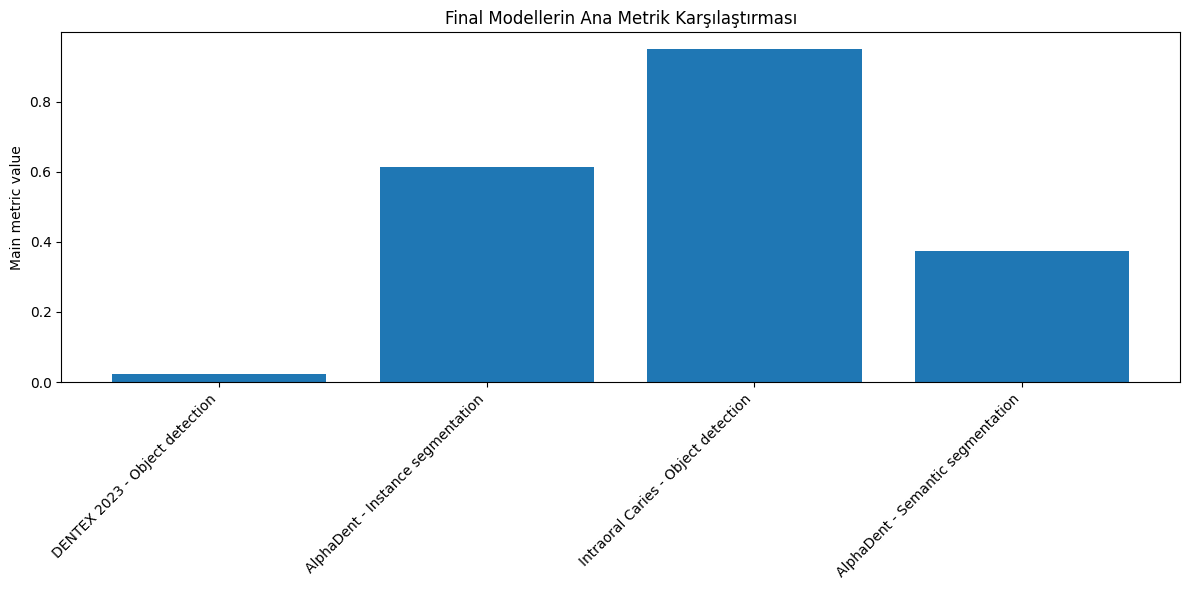

In [10]:
plot_df = df_final_models_summary.copy()

plt.figure(figsize=(12, 6))
plt.bar(plot_df["dataset"] + " - " + plot_df["task"], plot_df["main_metric_value"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Main metric value")
plt.title("Final Modellerin Ana Metrik Karşılaştırması")
plt.tight_layout()
plt.show()

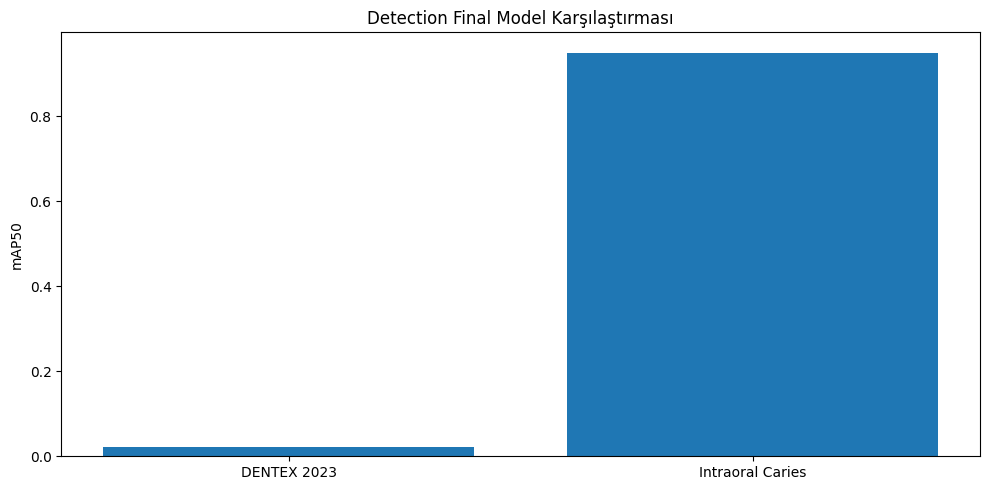

,dataset,image_type,task,final_model,run_name,imgsz,epochs,main_metric_name,main_metric_value,secondary_metric_name,secondary_metric_value,precision,recall,final_model_path
0,DENTEX 2023,Panoramic dental X-ray,Object detection,RT-DETR-l,rtdetr_l_640_30ep,640,30,mAP50,0.022853,mAP50-95,0.005516,0.684156,0.133065,/content/drive/MyDrive/DIS_PROJESI_007/final_m...
2,Intraoral Caries,Intraoral dental image,Object detection,RT-DETR-l,rtdetr_l_640_30ep,640,30,mAP50,0.950295,mAP50-95,0.758348,0.887644,0.889754,/content/drive/MyDrive/DIS_PROJESI_007/final_m...


In [11]:
df_detection_final = df_final_models_summary[
    df_final_models_summary["task"] == "Object detection"
].copy()

plt.figure(figsize=(10, 5))
plt.bar(df_detection_final["dataset"], df_detection_final["main_metric_value"])
plt.ylabel("mAP50")
plt.title("Detection Final Model Karşılaştırması")
plt.tight_layout()
plt.show()

df_detection_final

In [12]:
df_segmentation_final = df_final_models_summary[
    df_final_models_summary["dataset"] == "AlphaDent"
].copy()

df_segmentation_final

,dataset,image_type,task,final_model,run_name,imgsz,epochs,main_metric_name,main_metric_value,secondary_metric_name,secondary_metric_value,precision,recall,final_model_path
1,AlphaDent,Intraoral dental image,Instance segmentation,YOLOv8m-seg,yolov8m_seg_640_30ep,640,30,mask_mAP50,0.612124,mask_mAP50-95,0.411457,0.613126,0.585585,/content/drive/MyDrive/DIS_PROJESI_007/final_m...
3,AlphaDent,Intraoral dental image,Semantic segmentation,DeepLabV3+ ResNet34,deeplabv3plus_resnet34_512_30ep,512,30,val_mIoU,0.372880,best_epoch,16.000000,NaN,NaN,/content/drive/MyDrive/DIS_PROJESI_007/final_m...


In [13]:
dataset_interpretation = [
    {
        "dataset": "DENTEX 2023",
        "interpretation": "Panoramik X-ray görüntülerinde çürük, derin çürük ve periapikal lezyon tespiti zor kalmıştır. Düşük mAP değerleri, görüntü türü, sınıf dengesizliği ve bbox anotasyon yapısıyla ilişkilidir."
    },
    {
        "dataset": "AlphaDent",
        "interpretation": "Polygon anotasyonları sayesinde çürük ve diş aşınması bölgeleri segmentasyon tabanlı modellenmiştir. En iyi YOLO-seg sonucu YOLOv8m-seg ile elde edilmiştir."
    },
    {
        "dataset": "Intraoral Caries",
        "interpretation": "Tek sınıflı ağız içi çürük tespiti en başarılı deney grubu olmuştur. RT-DETR-l modeli yüksek mAP50 ve mAP50-95 değerleri vermiştir."
    },
    {
        "dataset": "AlphaDent DeepLabV3+",
        "interpretation": "DeepLabV3+ semantic segmentation için ek literatür modeli olarak denenmiştir. Val mIoU değeri YOLO-seg sonuçlarının gerisinde kalmış ve overfitting eğilimi gözlenmiştir."
    }
]

df_dataset_interpretation = pd.DataFrame(dataset_interpretation)
df_dataset_interpretation

,dataset,interpretation
0,DENTEX 2023,"Panoramik X-ray görüntülerinde çürük, derin çü..."
1,AlphaDent,Polygon anotasyonları sayesinde çürük ve diş a...
2,Intraoral Caries,Tek sınıflı ağız içi çürük tespiti en başarılı...
3,AlphaDent DeepLabV3+,DeepLabV3+ semantic segmentation için ek liter...


In [14]:
general_comment = """
Bu çalışmada üç farklı dental görüntü veri seti üzerinde nesne tespiti ve segmentasyon tabanlı derin öğrenme deneyleri gerçekleştirilmiştir.
DENTEX 2023 veri setinde panoramik dental X-ray görüntüleri üzerinde çürük, derin çürük ve periapikal lezyon sınıfları tespit edilmeye çalışılmıştır.
Bu veri setinde en iyi sonuç RT-DETR-l modeliyle elde edilmiş olsa da mAP değerleri düşük kalmıştır. Bu durum panoramik X-ray görüntülerinde küçük patolojik bulguların düşük görünürlüğü, sınıf dengesizliği ve anotasyonların hastalık bölgesini piksel hassasiyetinde temsil etmemesiyle ilişkilendirilmiştir.

AlphaDent veri setinde ağız içi görüntüler üzerinde diş çürüğü ve diş aşınması bölgeleri segmentasyon tabanlı olarak modellenmiştir.
YOLOv8n-seg, YOLOv8s-seg, YOLOv8m-seg ve YOLO11s-seg modelleri karşılaştırılmış; en iyi sonuç YOLOv8m-seg modeliyle elde edilmiştir.
YOLOv8m-seg modeli 640 görüntü boyutu ve 30 epoch eğitim ile mask_mAP50=0.6121 ve mask_mAP50-95=0.4115 değerlerine ulaşmıştır.

Intraoral Caries veri setinde tek sınıflı çürük tespiti yapılmıştır. Bu veri seti, ağız içi görüntülerde doğrudan çürük bölgelerine odaklandığı için en başarılı sonuçların elde edildiği veri seti olmuştur.
RT-DETR-l modeli 640 görüntü boyutu ve 30 epoch eğitim ile mAP50=0.9503 ve mAP50-95=0.7583 değerlerine ulaşmıştır.

Ek olarak, AlphaDent veri seti üzerinde DeepLabV3+ ResNet34 modeli semantic segmentation yaklaşımıyla denenmiştir.
DeepLabV3+ modeli en iyi 16. epochta val_mIoU=0.3729 değerine ulaşmıştır. Ancak eğitim ve doğrulama eğrileri overfitting eğilimi göstermiştir.
Bu nedenle AlphaDent için final model olarak YOLOv8m-seg tercih edilmiştir.

Genel olarak sonuçlar, dental görüntülerde model başarısının yalnızca model mimarisi veya epoch sayısına değil; veri setinin görüntü türüne, anotasyon formatına, sınıf dağılımına ve hedef patolojik bulgunun görünürlüğüne bağlı olduğunu göstermektedir.
"""

print(general_comment)


Bu çalışmada üç farklı dental görüntü veri seti üzerinde nesne tespiti ve segmentasyon tabanlı derin öğrenme deneyleri gerçekleştirilmiştir. 
DENTEX 2023 veri setinde panoramik dental X-ray görüntüleri üzerinde çürük, derin çürük ve periapikal lezyon sınıfları tespit edilmeye çalışılmıştır. 
Bu veri setinde en iyi sonuç RT-DETR-l modeliyle elde edilmiş olsa da mAP değerleri düşük kalmıştır. Bu durum panoramik X-ray görüntülerinde küçük patolojik bulguların düşük görünürlüğü, sınıf dengesizliği ve anotasyonların hastalık bölgesini piksel hassasiyetinde temsil etmemesiyle ilişkilendirilmiştir.

AlphaDent veri setinde ağız içi görüntüler üzerinde diş çürüğü ve diş aşınması bölgeleri segmentasyon tabanlı olarak modellenmiştir. 
YOLOv8n-seg, YOLOv8s-seg, YOLOv8m-seg ve YOLO11s-seg modelleri karşılaştırılmış; en iyi sonuç YOLOv8m-seg modeliyle elde edilmiştir. 
YOLOv8m-seg modeli 640 görüntü boyutu ve 30 epoch eğitim ile mask_mAP50=0.6121 ve mask_mAP50-95=0.4115 değerlerine ulaşmıştır.

Int

In [15]:
general_comment_path = GENERAL_RESULTS / "general_experimental_results_comment.txt"
general_comment_path.write_text(general_comment, encoding="utf-8")

interpretation_csv = GENERAL_RESULTS / "dataset_interpretation_summary.csv"
df_dataset_interpretation.to_csv(interpretation_csv, index=False)

print("Kaydedildi:")
print(general_comment_path)
print(interpretation_csv)

Kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/general_project_summary/general_experimental_results_comment.txt
/content/drive/MyDrive/DIS_PROJESI_007/results/general_project_summary/dataset_interpretation_summary.csv


In [16]:
df_report_final_table = df_final_models_summary[[
    "dataset",
    "image_type",
    "task",
    "final_model",
    "imgsz",
    "epochs",
    "main_metric_name",
    "main_metric_value",
    "secondary_metric_name",
    "secondary_metric_value"
]].copy()

df_report_final_table["main_metric_value"] = df_report_final_table["main_metric_value"].astype(float).round(4)
df_report_final_table["secondary_metric_value"] = df_report_final_table["secondary_metric_value"].astype(float).round(4)

df_report_final_table

,dataset,image_type,task,final_model,imgsz,epochs,main_metric_name,main_metric_value,secondary_metric_name,secondary_metric_value
0,DENTEX 2023,Panoramic dental X-ray,Object detection,RT-DETR-l,640,30,mAP50,0.0229,mAP50-95,0.0055
1,AlphaDent,Intraoral dental image,Instance segmentation,YOLOv8m-seg,640,30,mask_mAP50,0.6121,mask_mAP50-95,0.4115
2,Intraoral Caries,Intraoral dental image,Object detection,RT-DETR-l,640,30,mAP50,0.9503,mAP50-95,0.7583
3,AlphaDent,Intraoral dental image,Semantic segmentation,DeepLabV3+ ResNet34,512,30,val_mIoU,0.3729,best_epoch,16.0000


In [17]:
report_final_table_csv = GENERAL_RESULTS / "report_final_results_table.csv"

df_report_final_table.to_csv(report_final_table_csv, index=False)

print("Kaydedildi:")
print(report_final_table_csv)

Kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/general_project_summary/report_final_results_table.csv


In [18]:
print("09 General Project Results Summary tamamlandı.")
print("=" * 100)

print("Final model summary:")
display(df_final_models_summary)

print("\nRapor final sonuç tablosu:")
display(df_report_final_table)

print("\nVeri seti yorumları:")
display(df_dataset_interpretation)

print("\nGenel yorum dosyası:")
print(general_comment_path)

09 General Project Results Summary tamamlandı.
Final model summary:


,dataset,image_type,task,final_model,run_name,imgsz,epochs,main_metric_name,main_metric_value,secondary_metric_name,secondary_metric_value,precision,recall,final_model_path
0,DENTEX 2023,Panoramic dental X-ray,Object detection,RT-DETR-l,rtdetr_l_640_30ep,640,30,mAP50,0.022853,mAP50-95,0.005516,0.684156,0.133065,/content/drive/MyDrive/DIS_PROJESI_007/final_m...
1,AlphaDent,Intraoral dental image,Instance segmentation,YOLOv8m-seg,yolov8m_seg_640_30ep,640,30,mask_mAP50,0.612124,mask_mAP50-95,0.411457,0.613126,0.585585,/content/drive/MyDrive/DIS_PROJESI_007/final_m...
2,Intraoral Caries,Intraoral dental image,Object detection,RT-DETR-l,rtdetr_l_640_30ep,640,30,mAP50,0.950295,mAP50-95,0.758348,0.887644,0.889754,/content/drive/MyDrive/DIS_PROJESI_007/final_m...
3,AlphaDent,Intraoral dental image,Semantic segmentation,DeepLabV3+ ResNet34,deeplabv3plus_resnet34_512_30ep,512,30,val_mIoU,0.372880,best_epoch,16.000000,NaN,NaN,/content/drive/MyDrive/DIS_PROJESI_007/final_m...



Rapor final sonuç tablosu:


,dataset,image_type,task,final_model,imgsz,epochs,main_metric_name,main_metric_value,secondary_metric_name,secondary_metric_value
0,DENTEX 2023,Panoramic dental X-ray,Object detection,RT-DETR-l,640,30,mAP50,0.0229,mAP50-95,0.0055
1,AlphaDent,Intraoral dental image,Instance segmentation,YOLOv8m-seg,640,30,mask_mAP50,0.6121,mask_mAP50-95,0.4115
2,Intraoral Caries,Intraoral dental image,Object detection,RT-DETR-l,640,30,mAP50,0.9503,mAP50-95,0.7583
3,AlphaDent,Intraoral dental image,Semantic segmentation,DeepLabV3+ ResNet34,512,30,val_mIoU,0.3729,best_epoch,16.0000



Veri seti yorumları:


,dataset,interpretation
0,DENTEX 2023,"Panoramik X-ray görüntülerinde çürük, derin çü..."
1,AlphaDent,Polygon anotasyonları sayesinde çürük ve diş a...
2,Intraoral Caries,Tek sınıflı ağız içi çürük tespiti en başarılı...
3,AlphaDent DeepLabV3+,DeepLabV3+ semantic segmentation için ek liter...



Genel yorum dosyası:
/content/drive/MyDrive/DIS_PROJESI_007/results/general_project_summary/general_experimental_results_comment.txt
